In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import time

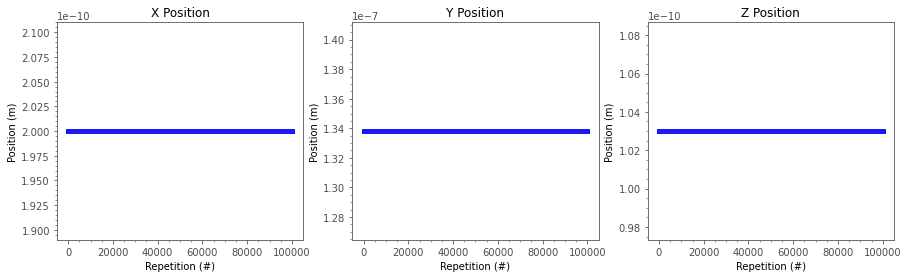

In [12]:
rep = 1e5
positions = []
x = np.zeros(int(rep))
y = np.zeros(int(rep))
z = np.zeros(int(rep))
for i in range(int(rep)):
    x[i] = spm._dev.scanner.getParameter(spm._dev.scanner.getConst('ID_SCAN_CURR_X'), 0)*1e-11
    y[i] = spm._dev.scanner.getParameter(spm._dev.scanner.getConst('ID_SCAN_CURR_Y'), 0)*1e-11
    z[i] = spm._dev.scanner.getParameter(spm._dev.scanner.getConst('ID_REG_GET_Z_M'), 0)*1e-12

fig = plt.figure(figsize=(15,4))
axX = fig.add_subplot(1, 3, 1)
axY = fig.add_subplot(1, 3, 2)
axZ = fig.add_subplot(1, 3, 3)
axX.plot(x)
axX.set_title('X Position')
axX.set_xlabel('Repetition (#)')
axX.set_ylabel('Position (m)')
axY.plot(y)
axY.set_title('Y Position')
axY.set_xlabel('Repetition (#)')
axY.set_ylabel('Position (m)')
axZ.plot(z)
axZ.set_title('Z Position')
axZ.set_xlabel('Repetition (#)')
axZ.set_ylabel('Position (m)')
plt.show()

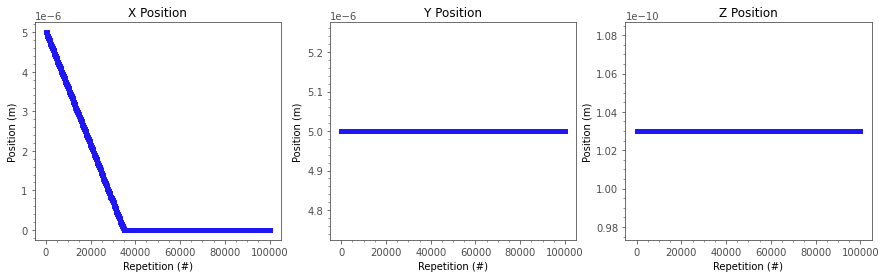

In [17]:
axis_dict = {"X":0e-6, "Y": 5e-6}
rep = 1e5
positions = []
x = np.zeros(int(rep))
y = np.zeros(int(rep))
z = np.zeros(int(rep))


const_dict = {'X' : 'ID_POSI_TARGET_X', 'Y' : 'ID_POSI_TARGET_Y', 'Z' : 'ID_REG_SET_Z_M'}
for i in axis_dict:
    if i[0].upper() == 'Z':
        axis_dict[i] *= 10 
    spm._dev.base.setParameter(spm._dev.base.getConst(const_dict[i[0].upper()]), axis_dict[i]*1e11, 0 )
    
spm._dev.base.setParameter(spm._dev.base.getConst('ID_POSI_GOTO'), 1, 0)

for i in range(int(rep)):
    x[i] = spm._dev.scanner.getParameter(spm._dev.scanner.getConst('ID_SCAN_CURR_X'), 0)*1e-11
    y[i] = spm._dev.scanner.getParameter(spm._dev.scanner.getConst('ID_SCAN_CURR_Y'), 0)*1e-11
    z[i] = spm._dev.scanner.getParameter(spm._dev.scanner.getConst('ID_REG_GET_Z_M'), 0)*1e-12

fig = plt.figure(figsize=(15,4))
axX = fig.add_subplot(1, 3, 1)
axY = fig.add_subplot(1, 3, 2)
axZ = fig.add_subplot(1, 3, 3)
axX.plot(x)
axX.set_title('X Position')
axX.set_xlabel('Repetition (#)')
axX.set_ylabel('Position (m)')
axY.plot(y)
axY.set_title('Y Position')
axY.set_xlabel('Repetition (#)')
axY.set_ylabel('Position (m)')
axZ.plot(z)
axZ.set_title('Z Position')
axZ.set_xlabel('Repetition (#)')
axZ.set_ylabel('Position (m)')
plt.show()

In [ ]:
coord0_origin = 2e-6
coord0_range = 2e-6
coord0_num = 100

coord1_origin = 2e-6
coord1_range = 2e-6
coord1_num = 100
rotation = 0

scan_array = afm_scanner_logic.create_scan_array(coord0_origin, coord0_range, coord0_num,
                                            coord1_origin, coord1_range,
                                            coord1_num, rotation)
x = []
y = []
z = []

for j in range(coord1_num):
    for i in range(coord0_num):
        target_x = scan_array[j,i,0]
        target_y = scan_array[j,i,1]
        axis_dict = {"X": target_x, "Y": target_y}
        const_dict = {'X' : 'ID_POSI_TARGET_X', 'Y' : 'ID_POSI_TARGET_Y', 'Z' : 'ID_REG_SET_Z_M'}
        for i in axis_dict:
            if i[0].upper() == 'Z':
                axis_dict[i] *= 10 
            spm._dev.base.setParameter(spm._dev.base.getConst(const_dict[i[0].upper()]), axis_dict[i]*1e11, 0 )

        spm._dev.base.setParameter(spm._dev.base.getConst('ID_POSI_GOTO'), 1, 0)
        
        loop_start = time.monotonic()
        while True:
            x_curr = spm._dev.scanner.getParameter(spm._dev.scanner.getConst('ID_SCAN_CURR_X'), 0)*1e-11
            y_curr = spm._dev.scanner.getParameter(spm._dev.scanner.getConst('ID_SCAN_CURR_Y'), 0)*1e-11
            z_curr = spm._dev.scanner.getParameter(spm._dev.scanner.getConst('ID_REG_GET_Z_M'), 0)*1e-12
            x.append(x_curr)
            y.append(y_curr)
            z.append(z_curr)
            a = np.array([x_curr, y_curr])
            b = np.array([target_x, target_y])
            if np.all(np.isclose(a, b, rtol=0, atol=1e-09, equal_nan=False)):
                break
            elif time.monotonic()-loop_start>2:
                break
        x.append(0)
        y.append(0)
        z.append(0)
        
x_plot = np.asarray(x, dtype=np.float32)
y_plot = np.asarray(y, dtype=np.float32)
z_plot = np.asarray(z, dtype=np.float32)

fig = plt.figure(figsize=(15,4))
axX = fig.add_subplot(1, 3, 1)
axY = fig.add_subplot(1, 3, 2)
axZ = fig.add_subplot(1, 3, 3)
axX.plot(x_plot)
axX.set_title('X Position')
axX.set_xlabel('Repetition (#)')
axX.set_ylabel('Position (m)')
axY.plot(y_plot)
axY.set_title('Y Position')
axY.set_xlabel('Repetition (#)')
axY.set_ylabel('Position (m)')
axZ.plot(z_plot)
axZ.set_title('Z Position')
axZ.set_xlabel('Repetition (#)')
axZ.set_ylabel('Position (m)')
plt.show()